## Final Project Write-up:

# Summary
In the code below, I am building a machine learning model that predicts the likelihood of a patient being readmitted within 30 days. In order to create the prediction I used a random forest classifier, which handles both categorical and numerical values. I used train.csv to train the model, validated the models accuracy with dev.csv and finally tested the model using test.csv. In the development phase the model received a ROC AUC score of 0.85 and in the testing phase it scored 0.82.

# EDA
All datasets have null values in both categorical and numerical columns. Some of the features needed to be encoded because they were non-numeric, object data types. Lastly columns used for targetting or had unique identifiers were dropped from the training dataset.

# Preprocessing
To prepare the data for the model I removed any columns that weren't in features. I dropped the target column as well so that the model could run properly. Next I encoded any categorical variables and filled any missing values. Preprocessed any numerical columns and filled missing values with the median from the train.csv dataset.

# Model choice
As mentioned in the summary, I used the random forest classifier as my ML model of choice. This model works well with both categorical and numerical values. Also handles multiple features well. After a few tries with the random forest classifier, I attempted using XGBoost to raise my ROC AUC score but it didn't work as well as my previous method. In my first few attempts I was stuck with a 0.76 score, but after modifying the code I was finally able to boost the score over 0.80. To check model performance I used the dev.csv dataset, then checked the ROC AUC local score to check how it performs.

# Model results
In the development phase I locally scored a 0.85, which was the same score in Codabench. In the testing phase I locally scored a 0.99, but after refinements in the code my Codabench score was 0.82.

# Interpret the model
To see what features impact a patient being readmitted within 30 days, I created a bar plot visual of the top 10 most important features. The variables that stood out to me the most were age, total procedure cost and total med cost. All of these are important factors if a patient will return to the hospital.

In [ ]:
## ML Coding starts:

# Load packages

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import zipfile

# Load training data & drop target columns

train_df = pd.read_csv("train.csv")
X_train = train_df.drop(columns=["encounter_id", "readmitted_within_30_days"])
y_train = train_df["readmitted_within_30_days"]

# Encode categorical columns

non_num_cols = X_train.select_dtypes(include='object').columns
for col in non_num_cols:
    X_train[col] = X_train[col].fillna("missing")
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])

# Preprocess numerical columns

num_cols = X_train.select_dtypes(include=np.number).columns
for col in num_cols:
    X_train[col] = X_train[col].fillna(X_train[col].median())

# Train model

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test.csv

test_df = pd.read_csv("dev.csv")
encounter_ids = test_df["encounter_id"]
X_test = test_df.drop(columns=["encounter_id", "readmitted_within_30_days"], errors="ignore")

# Preprocessing on test data

for col in non_num_cols:
    X_test[col] = X_test[col].fillna("missing").astype(str)
    X_test[col] = X_test[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)

for col in num_cols:
    X_test[col] = X_test[col].fillna(X_train[col].median())  # Use train medians

# Begin predictions

y_proba = model.predict_proba(X_test)[:, 1]

# Create submission file

submission = pd.DataFrame({
    "encounter_id": encounter_ids,
    "readmitted_within_30_days": y_proba
})
submission.to_csv("submission.csv", index=False)

with zipfile.ZipFile("submission.zip", "w") as zipf:
    zipf.write("submission.csv", arcname="submission.csv")
    zipf.write("dev.csv", arcname="dev.csv")

print("✅ Submission.zip created successfully.")


✅ Submission.zip created successfully.


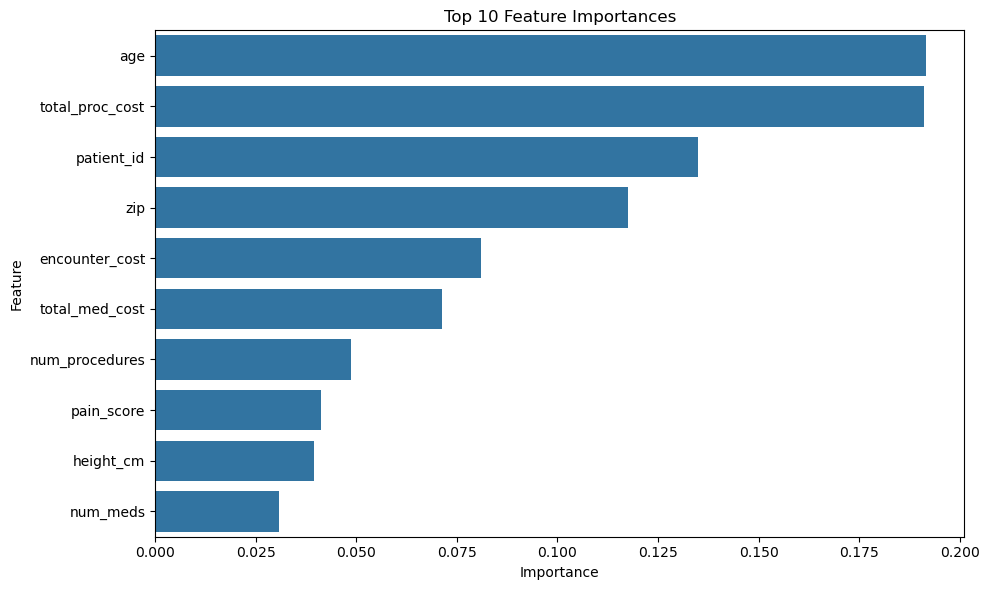

In [ ]:
## Visualize the model

# Import the necessary packages

import matplotlib.pyplot as plt
import seaborn as sns

# Build out visual

feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

# top 10 important features

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()